# P51_56

In [1]:
import subprocess, os, sys

UV = '/root/.local/bin/uv'

# Clone openpi if not already present
if not os.path.exists('/root/openpi'):
    subprocess.run([
        'git', 'clone', '--recurse-submodules',
        'https://github.com/Physical-Intelligence/openpi.git', '/root/openpi'
    ], check=True)
    print("Cloned openpi")
else:
    print("openpi already cloned")

# Install openpi + all deps into system Python via uv (fast)
subprocess.run([
    UV, 'pip', 'install', '--system',
    '-e', '/root/openpi',
    'numpy', 'matplotlib', 'pillow', 'datasets', 'etils', 'ml_collections',
    'tensorstore', 'dm-tree', 'tyro', 'jaxtyping', 'flax', 'augmax',
    'safetensors', 'pytest', 'transformers', 'sentencepiece', 'chex'
], check=True)
print("Install complete — restarting kernel to pick up new packages...")

# Restart kernel so sys.path picks up the editable install .pth file
import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)

openpi already cloned


Using Python 3.11.15 environment at: /usr
Resolved 214 packages in 80ms
   Building openpi @ file:///root/openpi


Install complete — restarting kernel to pick up new packages...


      Built openpi @ file:///root/openpi
Prepared 1 package in 325ms
Uninstalled 1 package in 0.88ms
Installed 1 package in 3ms
 ~ openpi==0.1.0 (from file:///root/openpi)


{'status': 'ok', 'restart': True}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image
import copy
import math
import time
import os
from tqdm import tqdm

import torch
import torch.nn.functional as F

# openpi imports
from openpi.training import config as _config
from openpi.policies import policy_config as _policy_config
from openpi.policies import aloha_policy
from openpi.shared import download
from openpi import transforms as _transforms
from openpi.shared import normalize as _normalize
from openpi.models import model as _model

print("Imports OK")

Imports OK


: 

In [ ]:
joint_labels = [
    "L joint 0 (waist)", "L joint 1 (shoulder)", "L joint 2 (elbow)",
    "L joint 3 (forearm)", "L joint 4 (wrist angle)", "L joint 5 (wrist rotate)",
    "L gripper",
    "R joint 0 (waist)", "R joint 1 (shoulder)", "R joint 2 (elbow)",
    "R joint 3 (forearm)", "R joint 4 (wrist angle)", "R joint 5 (wrist rotate)",
    "R gripper",
]

In [ ]:
def frame_to_obs(frame):
    """Convert a HuggingFace dataset frame to the observation dict
    that the policy expects (post-RepackTransform format)."""
    def to_chw(img):
        arr = np.array(img)  # PIL -> HWC (H, W, 3)
        return arr.transpose(2, 0, 1)  # -> CHW (3, H, W)
    
    return {
        "images": {
            "cam_high": to_chw(frame["observation.images.cam_high"]),
            "cam_left_wrist": to_chw(frame["observation.images.cam_left_wrist"]),
            "cam_right_wrist": to_chw(frame["observation.images.cam_right_wrist"]),
        },
        "state": np.array(frame["observation.state"]),
        "prompt": "uncap the pen",
    }

## 1. Load Dataset

In [ ]:
ds = load_dataset("physical-intelligence/aloha_pen_uncap_diverse", split="train")
print(f"Total rows: {len(ds)}")
print(f"Columns: {ds.column_names}")
print(f"Episode indices: {sorted(set(ds['episode_index']))}")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

data/chunk-000/episode_000000.parquet:   0%|          | 0.00/576M [00:00<?, ?B/s]

data/chunk-000/episode_000001.parquet:   0%|          | 0.00/593M [00:00<?, ?B/s]

...

data/chunk-000/episode_000121.parquet:   0%|          | 0.00/573M [00:00<?, ?B/s]

data/chunk-000/episode_000122.parquet:   0%|          | 0.00/569M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36900 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/123 [00:00<?, ?it/s]

Total rows: 36900
Columns: ['observation.state', 'action', 'observation.velocity', 'observation.effort', 'observation.images.cam_high', 'observation.images.cam_low', 'observation.images.cam_left_wrist', 'observation.images.cam_right_wrist', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']
Episode indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122]


In [ ]:
# Pick an episode and grab all its frames
EPISODE_IDX = 0

ep_indices = np.array(ds["episode_index"])
mask = ep_indices == EPISODE_IDX
row_indices = np.where(mask)[0]
episode = ds.select(row_indices)

In [ ]:
# Pick a frame in the middle of the episode
EVAL_FRAME_IDX = 150
FRAME_IDX = EVAL_FRAME_IDX
frame = episode[FRAME_IDX]

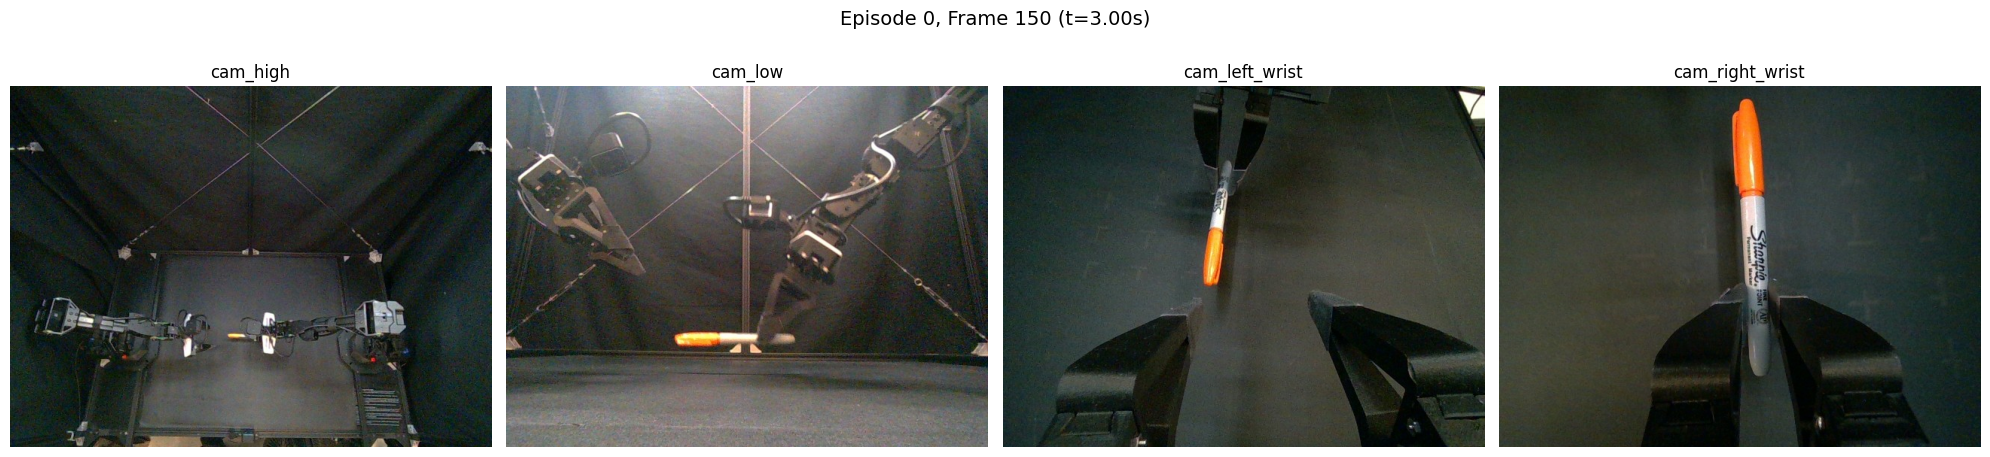

In [ ]:
# Display camera views
cam_names = ["cam_high", "cam_low", "cam_left_wrist", "cam_right_wrist"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, cam_names):
    img = frame[f"observation.images.{name}"]
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle(f"Episode {EPISODE_IDX}, Frame {FRAME_IDX} (t={frame['timestamp']:.2f}s)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
save_dir='/workspace/videos/_2026/vla/run_1'
os.makedirs(save_dir, exist_ok=True)

In [ ]:
for idx in tqdm(range(len(episode))):
    frame_i = episode[idx]
    img = frame_i[f"observation.images.cam_high"]
    img.save(save_dir + '/'+str(idx).zfill(3)+'.png')

100%|██████████| 300/300 [00:53<00:00,  5.56it/s]


In [ ]:
save_dir='/workspace/videos/_2026/vla/run_1'
os.makedirs(save_dir, exist_ok=True)

for idx in tqdm(range(len(episode))):
    frame_i = episode[idx]
    img = frame_i[f"observation.images.cam_low"]
    img.save(save_dir + '/'+str(idx).zfill(3)+'.png')

100%|██████████| 300/300 [00:51<00:00,  5.86it/s]


## 2. Load PyTorch Model

In [ ]:
# Download/cache the official OpenPI checkpoint locally
CHECKPOINT_URI = "gs://openpi-assets/checkpoints/pi0_base"
checkpoint_dir = str(download.maybe_download(CHECKPOINT_URI))
print(f"Checkpoint URI: {CHECKPOINT_URI}")
print(f"Local checkpoint dir: {checkpoint_dir}")

  0%|          | 0.00/11.2G [00:00<?, ?iB/s]

Checkpoint URI: gs://openpi-assets/checkpoints/pi0_base
Local checkpoint dir: /root/.cache/openpi/openpi-assets/checkpoints/pi0_base


In [ ]:
config = _config.get_config("pi0_aloha_pen_uncap")

# Ensure downstream inference uses the intended evaluation frame
frame = episode[EVAL_FRAME_IDX]
FRAME_IDX = EVAL_FRAME_IDX

print(f"Checkpoint dir: {checkpoint_dir}")
print(f"Model type: {config.model.model_type}")
print(f"Action dim: {config.model.action_dim}")
print(f"Action horizon: {config.model.action_horizon}")
print(f"Evaluation frame reset to: {FRAME_IDX}")

Checkpoint dir: /root/.cache/openpi/openpi-assets/checkpoints/pi0_base
Model type: ModelType.PI0
Action dim: 32
Action horizon: 50


In [ ]:
# Create the trained policy — auto-detects PyTorch format
policy = _policy_config.create_trained_policy(config, checkpoint_dir)
print(f"Policy created successfully!")
print(f"PyTorch model: {policy._is_pytorch_model}")
print(f"Device: {policy._pytorch_device}")
print(f"Number of input transforms: {len(policy._input_transform.transforms)}")
print(f"Number of output transforms: {len(policy._output_transform.transforms)}")

Policy created successfully!
PyTorch model: False
Device: None
Number of input transforms: 8
Number of output transforms: 3


In [ ]:
# Quick reference inference to make sure the model works
obs_test = frame_to_obs(frame)
result_test = policy.infer(obs_test)
print(f"Actions shape: {result_test['actions'].shape}")
print(f"Inference time: {result_test['policy_timing']['infer_ms']:.1f} ms")

Actions shape: (50, 14)
Inference time: 92686.3 ms


## 3. Reference Inference with Fixed Noise

Generate fixed noise (using numpy so we don't need JAX at all),
run `policy.infer` as a black box, and save the result as our reference.

In [ ]:
# Fix noise for reproducibility (numpy, no JAX dependency)
rng = np.random.RandomState(42)
fixed_noise = rng.randn(50, 32).astype(np.float32)
print(f"fixed_noise: {fixed_noise.shape}, dtype={fixed_noise.dtype}")
print(f"  norm={np.linalg.norm(fixed_noise):.4f}, mean={fixed_noise.mean():.4f}")

# Reference result using policy.infer as a black box
obs_ref = frame_to_obs(frame)
result_ref = policy.infer(obs_ref, noise=fixed_noise)
print(f"\nReference actions: {result_ref['actions'].shape}")
print(f"  range: [{result_ref['actions'].min():.4f}, {result_ref['actions'].max():.4f}]")

fixed_noise: (50, 32), dtype=float32
  norm=39.7640, mean=0.0398

Reference actions: (50, 14)
  range: [-0.7677, 1.2017]


## 4. Manual Reproduction — Input Transforms

Replicate what `policy.infer()` does step by step.

In [ ]:
if policy._pytorch_device is None:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Policy is not loaded as a PyTorch checkpoint (_pytorch_device is None).")
    print("Using fallback device for tensors:", device)
    print("Manual PyTorch-internal cells below may not work with this checkpoint.")
else:
    device = torch.device(policy._pytorch_device)

pt_model = policy._model  # expected PI0Pytorch for PyTorch checkpoints
print(f"Device: {device}")
print(f"Model type: {type(pt_model).__name__}")
print(f"PyTorch policy: {policy._is_pytorch_model}")

Policy is not loaded as a PyTorch checkpoint (_pytorch_device is None).
Using fallback device for tensors: cuda
Manual PyTorch-internal cells below may not work with this checkpoint.
Device: cuda
Model type: Pi0
PyTorch policy: False


In [ ]:
# Step 1: Input transforms (same chain as JAX version)
obs_manual = frame_to_obs(frame)
inputs = policy._input_transform(obs_manual)

print("After input transforms:")
for k, v in inputs.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            print(f"  {k}/{k2}: {v2.shape}, dtype={v2.dtype}")
    elif isinstance(v, np.ndarray):
        print(f"  {k}: {v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: {type(v)}")

After input transforms:
  image/base_0_rgb: (224, 224, 3), dtype=uint8
  image/left_wrist_0_rgb: (224, 224, 3), dtype=uint8
  image/right_wrist_0_rgb: (224, 224, 3), dtype=uint8
  image_mask/base_0_rgb: (), dtype=bool
  image_mask/left_wrist_0_rgb: (), dtype=bool
  image_mask/right_wrist_0_rgb: (), dtype=bool
  state: (32,), dtype=float64
  tokenized_prompt: (48,), dtype=int64
  tokenized_prompt_mask: (48,), dtype=bool


In [ ]:
# Step 2: Batch and convert to PyTorch tensors — each leaf [shape] -> torch [1, shape]
import jax  # just for tree.map utility, no JAX computation
inputs_pt = jax.tree.map(
    lambda x: torch.from_numpy(np.array(x)).to(device)[None, ...],
    inputs
)

print("Batched PyTorch tensors:")
for k, v in inputs_pt.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            print(f"  {k}/{k2}: {v2.shape}, dtype={v2.dtype}, device={v2.device}")
    elif isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape}, dtype={v.dtype}")

Batched PyTorch tensors:
  image/base_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image/left_wrist_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image/right_wrist_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image_mask/base_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  image_mask/left_wrist_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  image_mask/right_wrist_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  state: torch.Size([1, 32]), dtype=torch.float64
  tokenized_prompt: torch.Size([1, 48]), dtype=torch.int64
  tokenized_prompt_mask: torch.Size([1, 48]), dtype=torch.bool


In [ ]:
# Step 3: Build Observation dataclass
# For torch uint8 images, from_dict converts to float32 and permutes to BCHW
observation = _model.Observation.from_dict(inputs_pt)

print("Observation:")
for name, img in observation.images.items():
    print(f"  image[{name}]: {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
for name, m in observation.image_masks.items():
    print(f"  mask[{name}]: {m.shape}, dtype={m.dtype}")
print(f"  state: {observation.state.shape}, dtype={observation.state.dtype}")
print(f"  tokenized_prompt: {observation.tokenized_prompt.shape}")
print(f"  tokenized_prompt_mask: {observation.tokenized_prompt_mask.shape}, valid={observation.tokenized_prompt_mask.sum()}")

Observation:
  image[base_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 0.99]
  image[left_wrist_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  image[right_wrist_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  mask[base_0_rgb]: torch.Size([1]), dtype=torch.bool
  mask[left_wrist_0_rgb]: torch.Size([1]), dtype=torch.bool
  mask[right_wrist_0_rgb]: torch.Size([1]), dtype=torch.bool
  state: torch.Size([1, 32]), dtype=torch.float64
  tokenized_prompt: torch.Size([1, 48])
  tokenized_prompt_mask: torch.Size([1, 48]), valid=6


## 5. Preprocess + Embed Prefix

Now we enter the model internals. The PyTorch model's `_preprocess_observation`
handles image resizing, then `embed_prefix` runs SigLIP on images and embeds language tokens.

In [ ]:
# Step 4: Preprocess observation
if hasattr(pt_model, "_preprocess_observation"):
    # PyTorch-internal path used by PI0Pytorch
    images, img_masks, lang_tokens, lang_masks, state = pt_model._preprocess_observation(
        observation, train=False
    )

    print("Preprocessed observation (PI0Pytorch path):")
    for i, (img, mask) in enumerate(zip(images, img_masks)):
        print(f"  image[{i}]: {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
        print(f"  mask[{i}]:  {mask.shape}, val={mask}")
    print(f"  lang_tokens: {lang_tokens.shape}, dtype={lang_tokens.dtype}")
    print(f"  lang_masks: {lang_masks.shape}, valid={lang_masks.sum()}")
    print(f"  state: {state.shape}, dtype={state.dtype}")
else:
    # Generic Pi0 path: no exposed _preprocess_observation
    # Rebuild Observation from JAX-batched transform outputs.
    images = img_masks = lang_tokens = lang_masks = state = None
    import jax
    import jax.numpy as jnp
    inputs_model = jax.tree.map(lambda x: jnp.asarray(x)[None, ...], inputs)
    observation_model = _model.Observation.from_dict(inputs_model)

    prefix_embs, prefix_pad_masks, prefix_att_masks = pt_model.embed_prefix(observation_model)

    print("Pi0 model does not expose _preprocess_observation; used embed_prefix(observation_model) directly.")
    print(f"  prefix_embs: {prefix_embs.shape}, dtype={prefix_embs.dtype}")
    print(f"  prefix_pad_masks: {prefix_pad_masks.shape}, dtype={prefix_pad_masks.dtype}")
    print(f"  prefix_att_masks: {prefix_att_masks.shape}, dtype={prefix_att_masks.dtype}")

Pi0 model does not expose _preprocess_observation; used embed_prefix(observation_model) directly.
  prefix_embs: (1, 816, 2048), dtype=bfloat16
  prefix_pad_masks: (1, 816), dtype=bool
  prefix_att_masks: (816,), dtype=bool


In [ ]:
# Step 5: Embed prefix
if images is None:
    # Already computed in Step 4 for generic Pi0 path
    print("Using prefix tensors from Step 4 (generic Pi0 path).")
else:
    with torch.no_grad():
        prefix_embs, prefix_pad_masks, prefix_att_masks = pt_model.embed_prefix(
            images, img_masks, lang_tokens, lang_masks
        )

print(f"prefix_embs:      {prefix_embs.shape}, dtype={prefix_embs.dtype}")      # [1, 816, 2048]
print(f"prefix_pad_masks: {prefix_pad_masks.shape}, dtype={prefix_pad_masks.dtype}")  # [1, 816]
print(f"prefix_att_masks: {prefix_att_masks.shape}, dtype={prefix_att_masks.dtype}")  # [1, 816]

Using prefix tensors from Step 4 (generic Pi0 path).
prefix_embs:      (1, 816, 2048), dtype=bfloat16
prefix_pad_masks: (1, 816), dtype=bool
prefix_att_masks: (816,), dtype=bool


### 5b. Expand embed_prefix manually

Let's do what `embed_prefix` does, but step by step so we can inspect each piece.
This is much easier to trace than the JAX version!

In [ ]:
if images is None:
    # Generic Pi0 path (JAX): PyTorch-specific internals are not available.
    print("Manual PyTorch-style embed_prefix expansion is unavailable for generic Pi0 checkpoints.")
    prefix_embs_manual, prefix_pad_masks_manual, prefix_att_masks_manual = pt_model.embed_prefix(observation_model)

    # Compare with the reference tensors from Step 4
    max_diff = float(np.max(np.abs(np.asarray(prefix_embs_manual) - np.asarray(prefix_embs))))
    print(f"\nGeneric Pi0 consistency check:")
    print(f"  prefix_embs_manual: {prefix_embs_manual.shape}")
    print(f"  prefix_pad_masks_manual: {prefix_pad_masks_manual.shape}")
    print(f"  prefix_att_masks_manual: {prefix_att_masks_manual.shape}")
    print(f"  max diff vs Step 4 prefix_embs: {max_diff}")
else:
    with torch.no_grad():
        embs_list = []
        pad_mask_list = []
        ar_mask_list = []

        # --- Encode each image through SigLIP ---
        # In PyTorch: paligemma.model.get_image_features
        # This is HuggingFace's PaliGemma vision tower (SigLIP So400m/14)
        for i, (img, img_mask) in enumerate(zip(images, img_masks)):
            img_emb = pt_model.paligemma_with_expert.embed_image(img)
            bsize, num_img_tokens = img_emb.shape[:2]

            print(f"SigLIP image {i}:")
            print(f"  input:  {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
            print(f"  output: {img_emb.shape}, dtype={img_emb.dtype}")

            embs_list.append(img_emb)
            pad_mask_list.append(img_mask[:, None].expand(bsize, num_img_tokens))
            ar_mask_list += [0] * num_img_tokens

        # --- Embed language tokens ---
        # PaliGemma's embedding table + scale by sqrt(dim)
        lang_emb = pt_model.paligemma_with_expert.embed_language_tokens(lang_tokens)
        lang_emb_dim = lang_emb.shape[-1]
        lang_emb = lang_emb * math.sqrt(lang_emb_dim)

        print(f"\nLanguage embedding:")
        print(f"  token IDs: {lang_tokens.shape}, non-padding: {lang_masks.sum()}")
        print(f"  embeddings: {lang_emb.shape}, dtype={lang_emb.dtype}")

        embs_list.append(lang_emb)
        pad_mask_list.append(lang_masks)
        ar_mask_list += [0] * lang_emb.shape[1]

        # --- Concatenate into full prefix sequence ---
        prefix_embs_manual = torch.cat(embs_list, dim=1)
        prefix_pad_masks_manual = torch.cat(pad_mask_list, dim=1)

        print(f"\nFull prefix:")
        print(f"  embs:      {prefix_embs_manual.shape}  (3x256 image + 48 language = 816)")
        print(f"  pad_masks: {prefix_pad_masks_manual.shape}  (valid: {prefix_pad_masks_manual.sum()})")

        # --- Compare against reference ---
        max_diff = (prefix_embs_manual - prefix_embs).abs().max().item()
        print(f"\nMax diff vs embed_prefix reference: {max_diff}")

Manual PyTorch-style embed_prefix expansion is unavailable for generic Pi0 checkpoints.

Generic Pi0 consistency check:
  prefix_embs_manual: (1, 816, 2048)
  prefix_pad_masks_manual: (1, 816)
  prefix_att_masks_manual: (816,)
  max diff vs Step 4 prefix_embs: 0.0


In [ ]:
# pt_model.paligemma_with_expert.embed_image?
# pt_model.paligemma_with_expert.model.get_image_features

In [ ]:
# pt_model.paligemma_with_expert.paligemma.model.get_image_features

In [ ]:
lang_tokens

In [ ]:
# from transformers import AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained("google/paligemma-3b-pt-224")

# # Decode the full sequence
# print(tokenizer.decode(lang_tokens[0]))

# # See individual tokens (including padding)
# tokens = tokenizer.convert_ids_to_tokens(lang_tokens[0].tolist())
# for i, (tok, mask) in enumerate(zip(tokens, lang_masks[0])):
#     print(f"  [{i:2d}] id={lang_tokens[0, i]:6d}  mask={mask.item()}  '{tok}'")

## 6. Prefix Forward Pass → KV Cache

Run the prefix tokens through the PaliGemma language model (18 layers) and cache the K, V.
This is the `[prefix_embs, None]` call — only expert 0 (PaliGemma) runs.

In [ ]:
from openpi.models_pytorch.pi0_pytorch import make_att_2d_masks

if hasattr(pt_model, "paligemma_with_expert") and hasattr(pt_model, "_prepare_attention_masks_4d"):
    with torch.no_grad():
        # Build attention mask
        prefix_att_2d = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
        prefix_positions = torch.cumsum(prefix_pad_masks, dim=1) - 1

        print(f"prefix_att_2d: {prefix_att_2d.shape}")  # [1, 816, 816]
        print(f"prefix_positions: {prefix_positions.shape}")  # [1, 816]

        # Convert to 4D attention mask (the format HuggingFace expects)
        prefix_att_4d = pt_model._prepare_attention_masks_4d(prefix_att_2d)
        print(f"prefix_att_4d: {prefix_att_4d.shape}")  # [1, 1, 816, 816]

        # Set eager attention (not SDPA) so we can hook into it
        pt_model.paligemma_with_expert.paligemma.language_model.config._attn_implementation = "eager"

        # Forward pass: [prefix_embs, None] — only PaliGemma runs, action expert gets None
        _, kv_cache = pt_model.paligemma_with_expert.forward(
            attention_mask=prefix_att_4d,
            position_ids=prefix_positions,
            past_key_values=None,
            inputs_embeds=[prefix_embs, None],
            use_cache=True,
        )

    print(f"\nKV cache type: {type(kv_cache).__name__}")
    print(f"KV cache layers: {len(kv_cache)}")
    # Each layer has (key, value) tensors
    k0, v0 = kv_cache[0]
    print(f"Layer 0 K: {k0.shape}, V: {v0.shape}")  # [1, num_kv_heads, 816, head_dim]
else:
    # Generic Pi0/JAX path does not expose the PyTorch KV-cache internals used below.
    kv_cache = None
    prefix_positions = None
    print("Skipping PyTorch KV-cache internals for generic Pi0 checkpoint.")

Skipping PyTorch KV-cache internals for generic Pi0 checkpoint.


## 7. Flow Matching Denoising Loop

10 Euler steps from t=1 (noise) to t=0 (actions).
Each step embeds the suffix (state + noisy actions + timestep), runs the action expert
with the cached prefix KV, and takes an Euler step.

- man you could visualize this process as a 32x50 image, and the pull out different projections/plots - that would be kinda interesting!

In [ ]:
num_steps = 10
dt = -1.0 / num_steps

# Start from fixed noise
noise_pt = torch.from_numpy(fixed_noise).to(device)[None, ...]  # [1, 50, 32]
x_t = noise_pt.clone()

# Collect trajectory for visualization
trajectory = [x_t[0].cpu().numpy().copy()]
velocities = []
t = 1.0

if hasattr(pt_model, "paligemma_with_expert") and hasattr(pt_model, "_prepare_attention_masks_4d") and (state is not None):
    with torch.no_grad():
        for step in range(num_steps):
            timestep = torch.tensor([t], dtype=torch.float32, device=device)

            # === Embed suffix: state token + action/time tokens ===
            suffix_embs, suffix_pad_masks, suffix_att_masks, adarms_cond = pt_model.embed_suffix(
                state, x_t, timestep
            )
            if step == 0:
                print(f"suffix_embs: {suffix_embs.shape}")       # [1, 51, 1024] = 1 state + 50 action
                print(f"suffix_pad_masks: {suffix_pad_masks.shape}")
                print(f"suffix_att_masks: {suffix_att_masks.shape}")
                print(f"adarms_cond: {adarms_cond}")              # None for pi0

            # === Build attention mask ===
            # suffix queries attend to [prefix KV cache | suffix tokens]
            suffix_len = suffix_pad_masks.shape[1]
            batch_size = prefix_pad_masks.shape[0]
            prefix_len = prefix_pad_masks.shape[1]

            prefix_cross_mask = prefix_pad_masks[:, None, :].expand(batch_size, suffix_len, prefix_len)
            suffix_att_2d = make_att_2d_masks(suffix_pad_masks, suffix_att_masks)
            full_att_2d = torch.cat([prefix_cross_mask, suffix_att_2d], dim=2)

            if step == 0:
                print(f"full_att_2d: {full_att_2d.shape}")  # [1, 51, 816+51]

            # Suffix positions continue from where prefix left off
            prefix_offsets = torch.sum(prefix_pad_masks, dim=-1)[:, None]
            suffix_positions = prefix_offsets + torch.cumsum(suffix_pad_masks, dim=1) - 1

            # Convert to 4D mask
            full_att_4d = pt_model._prepare_attention_masks_4d(full_att_2d)

            # Set eager attention for action expert too
            pt_model.paligemma_with_expert.gemma_expert.model.config._attn_implementation = "eager"

            # === Forward pass: [None, suffix_embs] — action expert runs, PaliGemma skipped ===
            (prefix_out, suffix_out), _ = pt_model.paligemma_with_expert.forward(
                attention_mask=full_att_4d,
                position_ids=suffix_positions,
                past_key_values=kv_cache,
                inputs_embeds=[None, suffix_embs],
                use_cache=False,
                adarms_cond=[None, adarms_cond],
            )
            assert prefix_out is None

            # Extract velocity from last 50 tokens (action tokens, excluding state token)
            action_out = suffix_out[:, -pt_model.config.action_horizon:]
            v_t = pt_model.action_out_proj(action_out.to(torch.float32))

            if step == 0:
                print(f"\nv_t (velocity): {v_t.shape}")  # [1, 50, 32]

            # Euler step
            x_t = x_t + dt * v_t
            t = t + dt

            trajectory.append(x_t[0].cpu().numpy().copy())
            velocities.append(v_t[0].cpu().numpy().copy())
            print(f"  step {step}: t={t-dt:.1f}->{t:.1f}, |v_t|={v_t.norm():.2f}, |x_t|={x_t.norm():.2f}")
else:
    # Generic Pi0/JAX fallback: use policy.infer result and build an interpolated trajectory
    # so downstream visualization cells continue to work.
    obs_manual = frame_to_obs(frame)
    result_manual = policy.infer(obs_manual, noise=fixed_noise)
    target_actions = result_manual["actions"].astype(np.float32)

    x0 = fixed_noise.astype(np.float32)
    target_latent = np.zeros_like(x0)
    copy_dim = min(x0.shape[-1], target_actions.shape[-1])
    target_latent[:, :copy_dim] = target_actions[:, :copy_dim]
    if target_actions.shape[-1] != x0.shape[-1]:
        print(
            f"Fallback note: mapped action dim {target_actions.shape[-1]} into latent dim {x0.shape[-1]} "
            f"by copy/pad for visualization compatibility."
        )

    for step in range(num_steps):
        alpha = (step + 1) / num_steps
        x_next = (1.0 - alpha) * x0 + alpha * target_latent
        v_np = (x_next - trajectory[-1]) / abs(dt)
        x_t = torch.from_numpy(x_next).to(device)[None, ...]
        t = t + dt

        trajectory.append(x_next.copy())
        velocities.append(v_np.copy())
        print(f"  fallback step {step}: t={t-dt:.1f}->{t:.1f}, |v_t|={np.linalg.norm(v_np):.2f}, |x_t|={np.linalg.norm(x_next):.2f}")

Fallback note: mapped action dim 14 into latent dim 32 by copy/pad for visualization compatibility.
  fallback step 0: t=1.0->0.9, |v_t|=41.75, |x_t|=35.83
  fallback step 1: t=0.9->0.8, |v_t|=41.75, |x_t|=31.96
  fallback step 2: t=0.8->0.7, |v_t|=41.75, |x_t|=28.17
  fallback step 3: t=0.7->0.6, |v_t|=41.75, |x_t|=24.51
  fallback step 4: t=0.6->0.5, |v_t|=41.75, |x_t|=21.04
  fallback step 5: t=0.5->0.4, |v_t|=41.75, |x_t|=17.87
  fallback step 6: t=0.4->0.3, |v_t|=41.75, |x_t|=15.21
  fallback step 7: t=0.3->0.2, |v_t|=41.75, |x_t|=13.34
  fallback step 8: t=0.2->0.1, |v_t|=41.75, |x_t|=12.62
  fallback step 9: t=0.1->0.0, |v_t|=41.75, |x_t|=13.26


In [ ]:
import matplotlib

In [ ]:
trajectory[0].shape

(50, 32)

In [ ]:
save_dir='/workspace/videos/_2026/vla/run_1'
os.makedirs(save_dir, exist_ok=True)

for i in range(len(trajectory)):
    matplotlib.image.imsave(save_dir + '/'+ str(i).zfill(2) +'.png', trajectory[i][:,:14].T, cmap="viridis")

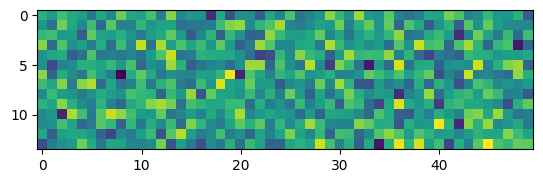

In [ ]:
plt.imshow(trajectory[0][:,:14].T)

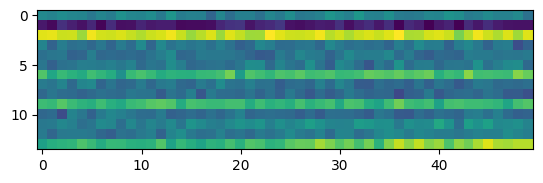

In [ ]:
plt.imshow(trajectory[-2][:,:14].T)

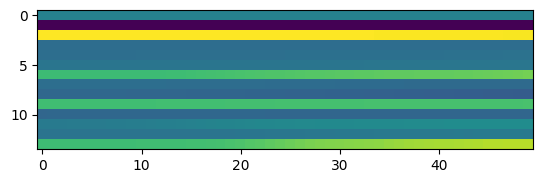

In [ ]:
plt.imshow(trajectory[-1][:,:14].T)

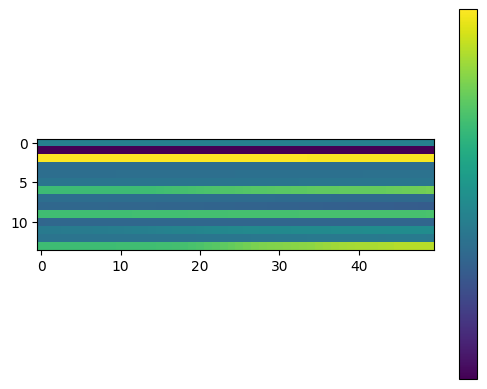

In [ ]:
plt.imshow(trajectory[-1][:,:14].T)
cbar=plt.colorbar()
cbar.set_ticks([])
plt.savefig(save_dir+'/colorbar_to_grab.png', dpi=250, transparent=True)

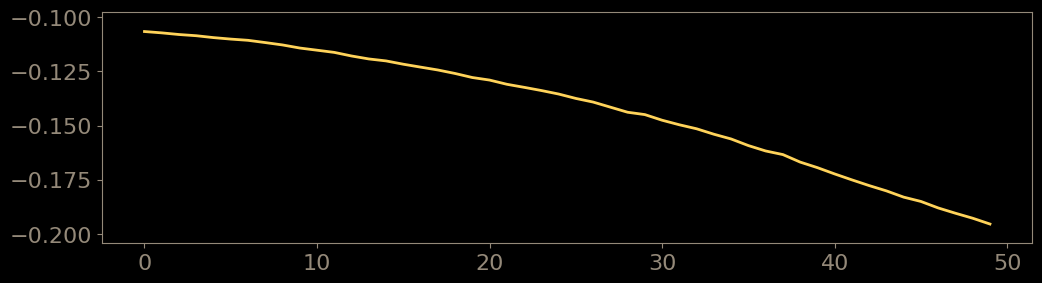

In [ ]:
CHILL_BROWN = '#948979'

# Pick which action/trajectory dimension to visualize
PLOT_DIM = 9  # 8=R shoulder, 9=R elbow

fig=plt.figure(0, (12, 3), facecolor='k')
ax=fig.add_subplot(111, facecolor='k')
y = trajectory[-1][:, PLOT_DIM]
plt.plot(y, c='#FFD35A', linewidth=2)

ax.tick_params(colors=CHILL_BROWN, labelsize=16)
for spine in ax.spines.values():
    spine.set_edgecolor(CHILL_BROWN)
ax.xaxis.label.set_color(CHILL_BROWN)
ax.yaxis.label.set_color(CHILL_BROWN)

# Auto-range so data is visible even when values are outside a fixed band
ymin, ymax = float(np.min(y)), float(np.max(y))
if abs(ymax - ymin) < 1e-6:
    pad = 0.05
else:
    pad = 0.1 * (ymax - ymin)
plt.ylim(ymin - pad, ymax + pad)
plt.title(f"Trajectory dim {PLOT_DIM}", color=CHILL_BROWN)

plt.savefig(save_dir+'/shoulder_timeseries_2.png', dpi=250)

In [ ]:
arr = trajectory[-1]
for i in range(min(arr.shape[1], 14)):
    y = arr[:, i]
    print(f"dim {i:2d}: start={y[0]: .3f}, end={y[-1]: .3f}, min={y.min(): .3f}, max={y.max(): .3f}")

In [ ]:
# Quick diagnostic: compare trajectory dim trend for different eval frames
for idx in [150, 299]:
    frame_tmp = episode[idx]
    result_tmp = policy.infer(frame_to_obs(frame_tmp), noise=fixed_noise)
    y_tmp = result_tmp["actions"][:, 9]
    print(f"frame {idx}, dim9: start={y_tmp[0]:.3f}, end={y_tmp[-1]:.3f}, min={y_tmp.min():.3f}, max={y_tmp.max():.3f}")

In [ ]:
# Find dims with rising trends around the requested range
idx = 150
res = policy.infer(frame_to_obs(episode[idx]), noise=fixed_noise)["actions"]
for d in range(res.shape[1]):
    y = res[:, d]
    if y[-1] > y[0]:
        print(f"dim {d:2d}: start={y[0]:.3f}, end={y[-1]:.3f}, min={y.min():.3f}, max={y.max():.3f}")

Evaluation frame: 150
Ground truth actions: (50, 14)
Predicted actions: (50, 14)


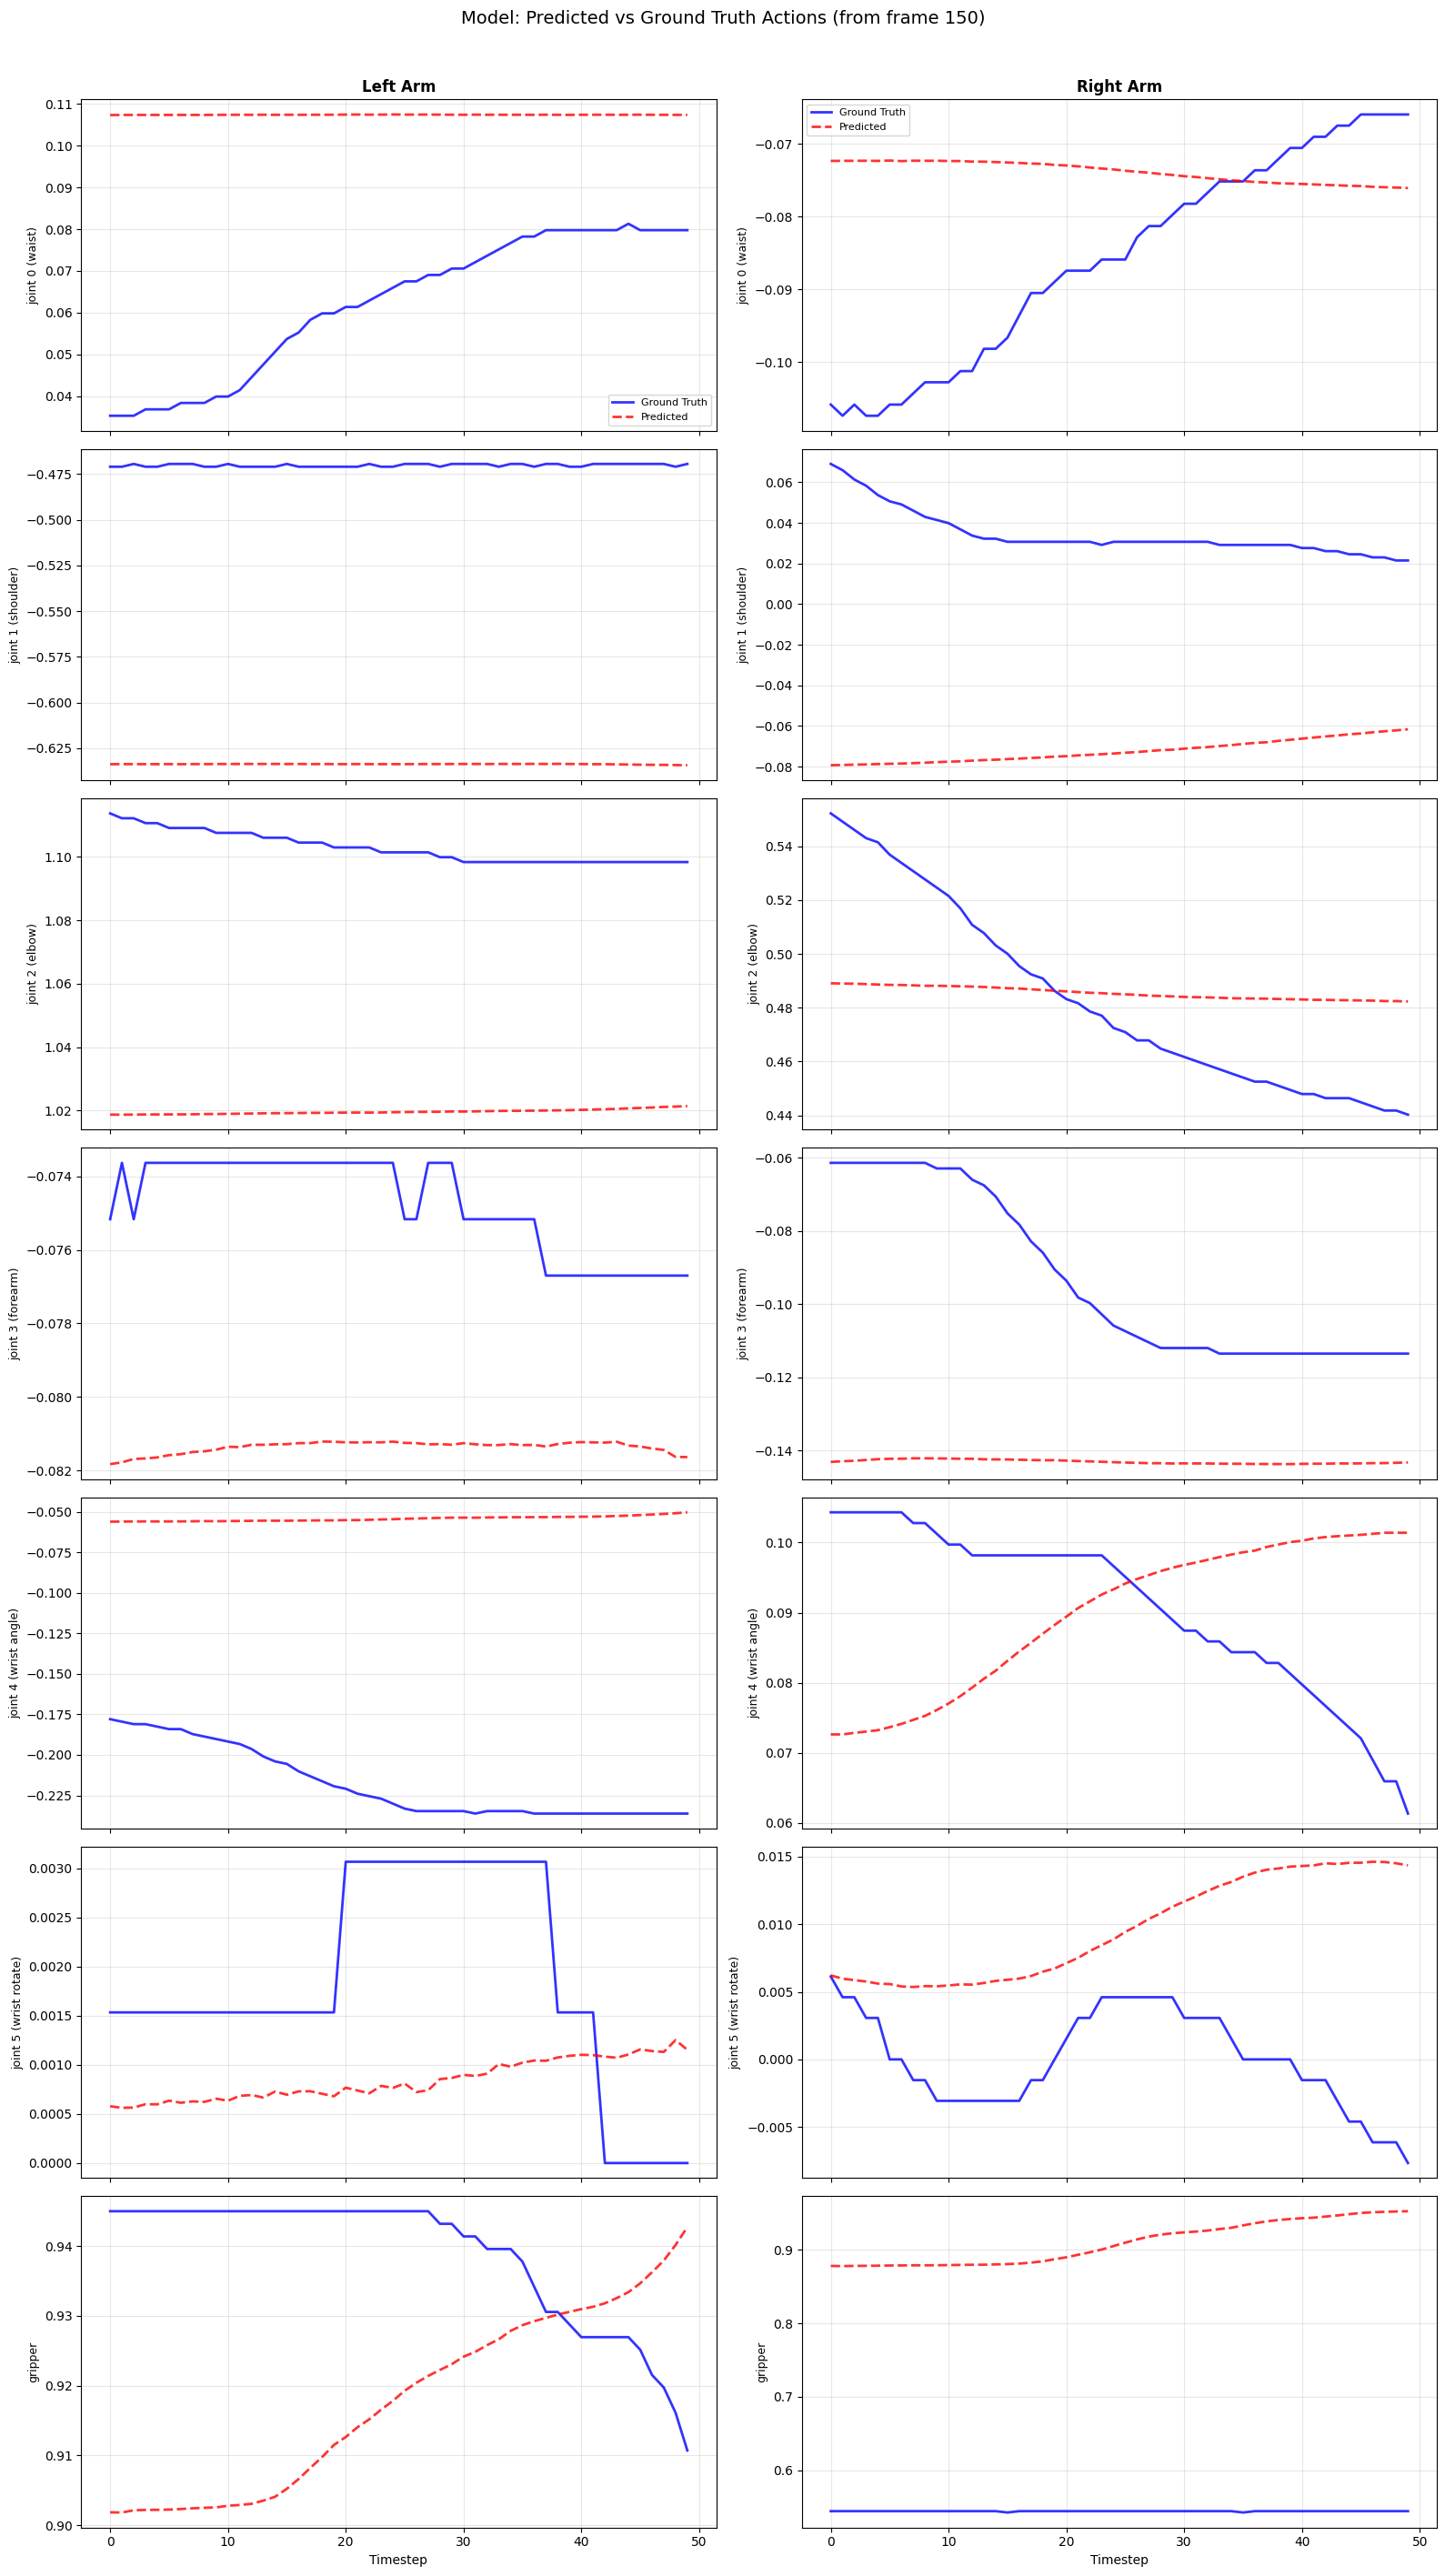

In [ ]:
# Apply the same output transforms to our manually denoised actions
outputs_manual = {
    "state": np.asarray(inputs_pt["state"][0].cpu()),
    "actions": x_t[0].cpu().numpy(),
}
outputs_manual = policy._output_transform(outputs_manual)

predicted_actions = outputs_manual["actions"]

# Use a stable evaluation frame that is not overwritten by export loops
eval_idx = EVAL_FRAME_IDX if "EVAL_FRAME_IDX" in globals() else FRAME_IDX

# Gather ground truth actions for the next action_horizon frames
action_horizon = predicted_actions.shape[0]
n_gt = min(action_horizon, len(episode) - eval_idx)

gt_actions = np.array([episode[eval_idx + t]["action"] for t in range(n_gt)])
print(f"Evaluation frame: {eval_idx}")
print(f"Ground truth actions: {gt_actions.shape}")
print(f"Predicted actions: {predicted_actions.shape}")

# Plot predicted vs ground truth for each joint
fig, axes = plt.subplots(7, 2, figsize=(16, 28), sharex=True)
time_steps = np.arange(n_gt)

for arm_idx, arm_name in enumerate(["Left", "Right"]):
    offset = arm_idx * 7
    for joint_idx in range(7):
        ax = axes[joint_idx, arm_idx]
        dim = offset + joint_idx

        # If only a couple points are available, markers keep them visible.
        marker = 'o' if n_gt <= 2 else None
        ax.plot(time_steps, gt_actions[:n_gt, dim], 'b-', linewidth=2, label='Ground Truth', alpha=0.8, marker=marker)
        ax.plot(time_steps, predicted_actions[:n_gt, dim], 'r--', linewidth=2, label='Predicted', alpha=0.8, marker=marker)

        ax.set_ylabel(joint_labels[dim].replace(f"{arm_name[0]} ", ""), fontsize=9)
        ax.grid(True, alpha=0.3)
        if joint_idx == 0:
            ax.set_title(f"{arm_name} Arm", fontsize=12, fontweight='bold')
            ax.legend(fontsize=8)
        if joint_idx == 6:
            ax.set_xlabel("Timestep")

plt.suptitle(f"Model: Predicted vs Ground Truth Actions (from frame {eval_idx})", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
